Подключим все нужные библиотеки и загрузим таблицу

In [15]:
import pathlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

work_path = pathlib.Path.cwd()
data_path = Path(work_path, 'jewelry', 'jewelry - jewelry.csv')
df = pd.read_csv(data_path)

C:\Users\79276\AppData\Local\Temp\ipykernel_28200\3632617051.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Выведем таблицу(первые 5 строчек)

In [16]:
df.head()

,Order datetime,Order ID,Purchased product ID,Quantity of SKU in the order,Category ID,Category alias,Brand ID,Price in USD,User ID,Product gender,Main color,Main metal,Main gem
0,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1.806829e+18,jewelry.earring,0.0,561.51,1515915625207851155,NaN,red,gold,diamond
1,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1515915625071969944,NaN,yellow,gold,NaN
2,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1515915625048493557,f,white,gold,sapphire
3,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1515915625207630915,f,red,gold,diamond
4,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1515915625175329378,NaN,red,gold,amethyst


Теперь ввыведем основную  информацию из таблицы

In [17]:
print("Размер датасета:", df.shape)
print("Заголовки столбцов:")
print(df.columns.tolist())

print("Сводная информация:")
df.info()

Размер датасета: (95911, 13)
Заголовки столбцов:
['Order datetime', 'Order ID', 'Purchased product ID', 'Quantity of SKU in the order', 'Category ID', 'Category alias', 'Brand ID', 'Price in USD', 'User ID', 'Product gender', 'Main color', 'Main metal', 'Main gem']
Сводная информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95911 entries, 0 to 95910
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Order datetime                95911 non-null  object 
 1   Order ID                      95911 non-null  object 
 2   Purchased product ID          95911 non-null  object 
 3   Quantity of SKU in the order  95911 non-null  int64  
 4   Category ID                   90559 non-null  float64
 5   Category alias                85978 non-null  object 
 6   Brand ID                      91126 non-null  float64
 7   Price in USD                  90559 non-null  float64
 8   User ID   

Рассмотрим строки с пропущенными и повторяющимися значениями 

In [18]:
print("Пропущенные значения:")
print(df.isnull().sum())

print(f"\nКоличество дубликатов: {df.duplicated().sum()}")
df.head(10)

Пропущенные значения:
Order datetime                      0
Order ID                            0
Purchased product ID                0
Quantity of SKU in the order        0
Category ID                      5352
Category alias                   9933
Brand ID                         4785
Price in USD                     5352
User ID                          5352
Product gender                  48168
Main color                       7660
Main metal                       5462
Main gem                        34058
dtype: int64

Количество дубликатов: 2589


,Order datetime,Order ID,Purchased product ID,Quantity of SKU in the order,Category ID,Category alias,Brand ID,Price in USD,User ID,Product gender,Main color,Main metal,Main gem
0,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1.806829e+18,jewelry.earring,0.0,561.51,1515915625207851155,NaN,red,gold,diamond
1,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1515915625071969944,NaN,yellow,gold,NaN
2,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1515915625048493557,f,white,gold,sapphire
3,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1515915625207630915,f,red,gold,diamond
4,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1515915625175329378,NaN,red,gold,amethyst
5,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1515915625234475782,NaN,red,gold,NaN
6,2018-12-02 22:09:34 UTC,1925760595336888995,1600021442638905547,1,1.806829e+18,jewelry.earring,0.0,150.55,1515915625234475782,NaN,red,gold,diamond
7,2018-12-02 22:16:20 UTC,1925764002260976330,1835566854106513435,1,1.806829e+18,jewelry.earring,0.0,83.42,1515915625210832627,NaN,white,gold,fianit
8,2018-12-03 07:03:49 UTC,1926029494397698277,1811798112444875309,1,1.806829e+18,jewelry.pendant,2.0,60.27,1515915625234339329,f,red,gold,pearl
9,2018-12-03 09:48:34 UTC,1926112416450478161,1836278824443052965,1,1.806829e+18,jewelry.earring,1.0,217.40,1515915625081825388,NaN,red,gold,diamond


Заполняем столбцы с пустыми строчками средним значением или самым популярным выбором покупателем

In [19]:
df['Category ID'] = pd.to_numeric(df['Category ID'], errors='coerce')
df['User ID'] = pd.to_numeric(df['User ID'], errors='coerce')
df['Brand ID'] = pd.to_numeric(df['Brand ID'], errors='coerce')
df['Price in USD'] = pd.to_numeric(df['Price in USD'], errors='coerce')

# Заполняем пропуски БЕЗ inplace
df['Brand ID'] = df['Brand ID'].fillna(df['Brand ID'].mean())
df['Category ID'] = df['Category ID'].fillna(df['Category ID'].mean())
df['User ID'] = df['User ID'].fillna(df['User ID'].mean()) 
df['Price in USD'] = df['Price in USD'].fillna(df['Price in USD'].mean())
df['Brand ID'] = df['Brand ID'].fillna(df['Brand ID'].mean())
df['Category alias'] = df['Category alias'].fillna(df['Category alias'].mode()[0])
df['Product gender'] = df['Product gender'].fillna(df['Product gender'].mode()[0])
df['Main color'] = df['Main color'].fillna(df['Main color'].mode()[0])
df['Main metal'] = df['Main metal'].fillna(df['Main metal'].mode()[0])
df['Main gem'] = df['Main gem'].fillna(df['Main gem'].mode()[0])

print("Пропуски после заполнения: ")
print(df.isnull().sum())

df.head(10)

Пропуски после заполнения: 
Order datetime                  0
Order ID                        0
Purchased product ID            0
Quantity of SKU in the order    0
Category ID                     0
Category alias                  0
Brand ID                        0
Price in USD                    0
User ID                         0
Product gender                  0
Main color                      0
Main metal                      0
Main gem                        0
dtype: int64


,Order datetime,Order ID,Purchased product ID,Quantity of SKU in the order,Category ID,Category alias,Brand ID,Price in USD,User ID,Product gender,Main color,Main metal,Main gem
0,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1.806829e+18,jewelry.earring,0.000000e+00,561.51,1.515916e+18,f,red,gold,diamond
1,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,jewelry.earring,8.890938e+16,212.14,1.515916e+18,f,yellow,gold,diamond
2,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.000000e+00,54.66,1.515916e+18,f,white,gold,sapphire
3,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.000000e+00,88.90,1.515916e+18,f,red,gold,diamond
4,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.000000e+00,417.67,1.515916e+18,f,red,gold,amethyst
5,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.000000e+00,102.27,1.515916e+18,f,red,gold,diamond
6,2018-12-02 22:09:34 UTC,1925760595336888995,1600021442638905547,1,1.806829e+18,jewelry.earring,0.000000e+00,150.55,1.515916e+18,f,red,gold,diamond
7,2018-12-02 22:16:20 UTC,1925764002260976330,1835566854106513435,1,1.806829e+18,jewelry.earring,0.000000e+00,83.42,1.515916e+18,f,white,gold,fianit
8,2018-12-03 07:03:49 UTC,1926029494397698277,1811798112444875309,1,1.806829e+18,jewelry.pendant,2.000000e+00,60.27,1.515916e+18,f,red,gold,pearl
9,2018-12-03 09:48:34 UTC,1926112416450478161,1836278824443052965,1,1.806829e+18,jewelry.earring,1.000000e+00,217.40,1.515916e+18,f,red,gold,diamond


Выведем украшение с максимальной ценой и украшение с минимальной ценой

In [20]:
jewelry_categories = ['jewelry.earring', 'jewelry.ring', 'jewelry.pendant', 'jewelry.bracelet', 'jewelry.necklace', 'jewelry.brooch']
df_jewelry = df[df['Category alias'].isin(jewelry_categories)]

stats = df_jewelry.groupby('Category alias')['Price in USD'].agg(['min', 'max'])

print("Статистика только по jewelry категориям:")
print(stats)

Статистика только по jewelry категориям:
                    min       max
Category alias                   
jewelry.bracelet   6.47   4202.74
jewelry.brooch     6.71   3088.90
jewelry.earring    6.85  34448.60
jewelry.necklace  34.11   3482.16
jewelry.pendant    0.99   7513.56
jewelry.ring       2.60  26424.52


Построим линейный график цен украшений

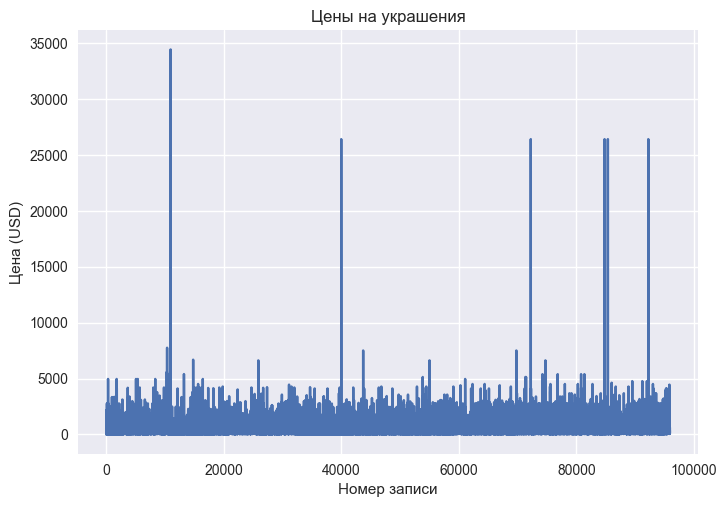

In [21]:
df['Price in USD'].plot(kind='line', title='Цены на украшения')
plt.xlabel('Номер записи')
plt.ylabel('Цена (USD)')
plt.show()

Рассмотрим графики относительно категоральных признаков

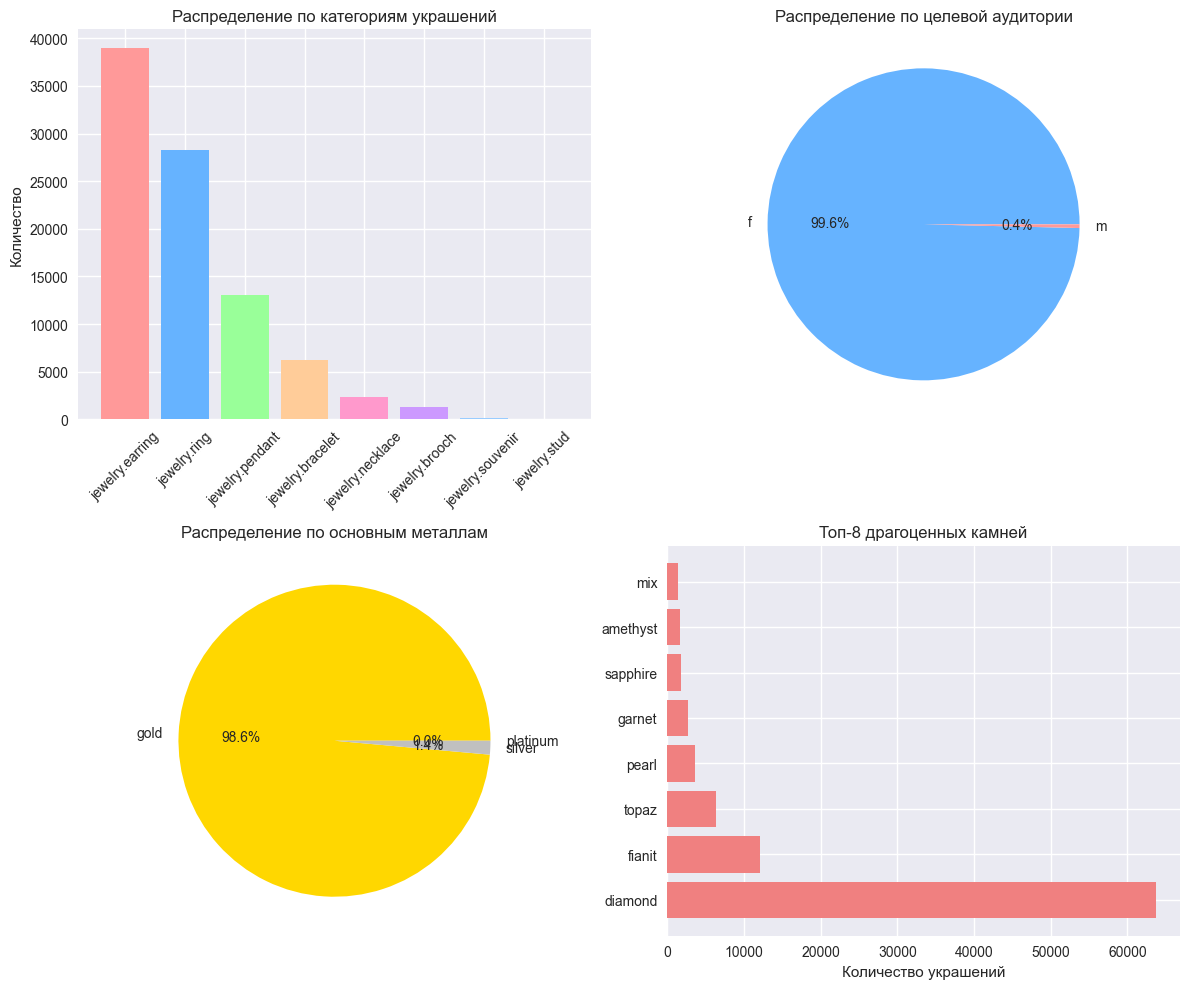

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Распределение по категориям украшений (столбчатая диаграмма)
df_jewelry = df[df['Category alias'].str.startswith('jewelry.', na=False)]
category_counts = df_jewelry['Category alias'].value_counts().head(8)
axes[0,0].bar(category_counts.index, category_counts.values, 
             color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#cc99ff', '#99ccff', '#ffcc66'])
axes[0,0].set_title('Распределение по категориям украшений')
axes[0,0].set_ylabel('Количество')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Распределение по полу (круговая диаграмма)
gender_counts = df['Product gender'].value_counts()
colors_gender = ['#66b3ff', '#ff9999', '#99ff99']  
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
             colors=colors_gender[:len(gender_counts)])
axes[0,1].set_title('Распределение по целевой аудитории')

# 3. Распределение по основным металлам (круговая диаграмма)
metal_counts = df['Main metal'].value_counts().head(5)  
colors_metal = ['#FFD700', '#C0C0C0', '#CD7F32', '#E5E4E2', '#B9D9EB']  
axes[1,0].pie(metal_counts.values, labels=metal_counts.index, autopct='%1.1f%%', 
             colors=colors_metal[:len(metal_counts)])
axes[1,0].set_title('Распределение по основным металлам')

# 4. Топ драгоценных камней (горизонтальная столбчатая диаграмма)
top_gems = df['Main gem'].value_counts().head(8)  # Топ-8 камней
axes[1,1].barh(top_gems.index, top_gems.values, color='lightcoral')
axes[1,1].set_title('Топ-8 драгоценных камней')
axes[1,1].set_xlabel('Количество украшений')

plt.tight_layout()
plt.show()

Рассмотрим графики относительно числовых признаков 

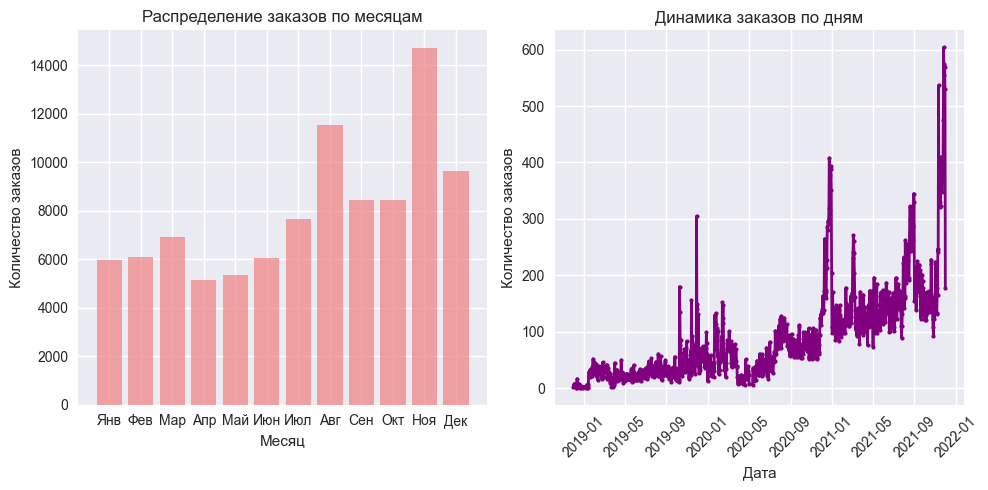

In [23]:
# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 1. Распределение по месяцам (аналог decade)
df['Order datetime'] = pd.to_datetime(df['Order datetime'])
df['month'] = df['Order datetime'].dt.month
month_counts = df['month'].value_counts().sort_index()
axes[0].bar(month_counts.index, month_counts.values, color='lightcoral', alpha=0.7)
axes[0].set_title('Распределение заказов по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество заказов')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                         'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])

# 2. Динамика заказов по дням (аналог date)
df['order_date'] = df['Order datetime'].dt.date
daily_counts = df['order_date'].value_counts().sort_index()
axes[1].plot(daily_counts.index, daily_counts.values, marker='o', linewidth=2, color='purple', markersize=3)
axes[1].set_title('Динамика заказов по дням')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Количество заказов')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Выведем еще две диаграммы

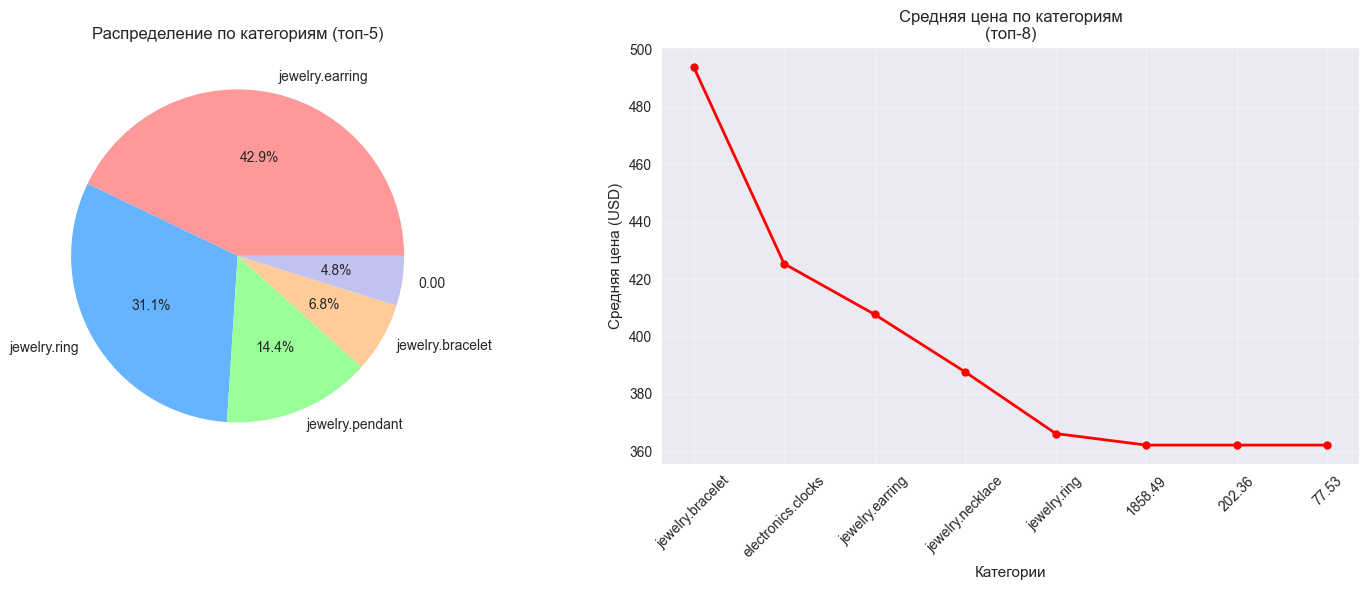

In [24]:
# Создаем фигуру с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. КРУГОВАЯ ДИАГРАММА - распределение по категориям
category_counts = df['Category alias'].value_counts().head(5) 
axes[0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
           colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'])
axes[0].set_title('Распределение по категориям (топ-5)')

# 2. ЛИНЕЙНЫЙ ГРАФИК - средняя цена по категориям
category_prices = df.groupby('Category alias')['Price in USD'].mean().sort_values(ascending=False).head(8)
axes[1].plot(category_prices.index, category_prices.values, marker='o', linewidth=2, 
            color='red', markersize=6)
axes[1].set_title('Средняя цена по категориям\n(топ-8)')
axes[1].set_xlabel('Категории')
axes[1].set_ylabel('Средняя цена (USD)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Определим числовые и категоральные признаки

In [25]:
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in df.columns if df[c].dtype == 'O']
print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)


Числовые признаки: ['Quantity of SKU in the order', 'Category ID', 'Brand ID', 'Price in USD', 'User ID', 'month']
Категориальные признаки: ['Order ID', 'Purchased product ID', 'Category alias', 'Product gender', 'Main color', 'Main metal', 'Main gem', 'order_date']


Посчитаем выбросы для одного столбца

In [26]:
column = 'Price in USD'

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Границы для {column}: [{lower_bound:.2f}, {upper_bound:.2f}]")
outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
print(f"Количество выбросов: {outliers_count}")

Границы для Price in USD: [-245.48, 814.25]
Количество выбросов: 7018


Теперь заменим выбросы на границы

In [27]:
# Замена выбросов
df_capped = df.copy()
df_capped.loc[df_capped[column] < lower_bound, column] = lower_bound
df_capped.loc[df_capped[column] > upper_bound, column] = upper_bound

print("Выбросы заменены на граничные значения!")

Выбросы заменены на граничные значения!


Разделим столбец Order Time на два раздельных столбца

In [30]:
# Преобразуем в datetime тип
df['Order datetime'] = pd.to_datetime(df['Order datetime'])

# Создаем отдельные столбцы
df['Order Date'] = df['Order datetime'].dt.date
df['Order Time'] = df['Order datetime'].dt.time

df.head()

,Order datetime,Order ID,Purchased product ID,Quantity of SKU in the order,Category ID,Category alias,Brand ID,Price in USD,User ID,Product gender,Main color,Main metal,Main gem,month,order_date,Order Date,Order Time
0,2018-12-01 11:40:29+00:00,1924719191579951782,1842195256808833386,1,1.806829e+18,jewelry.earring,0.000000e+00,561.51,1.515916e+18,f,red,gold,diamond,12,2018-12-01,2018-12-01,11:40:29
1,2018-12-01 17:38:31+00:00,1924899396621697920,1806829193678291446,1,1.806829e+18,jewelry.earring,8.890938e+16,212.14,1.515916e+18,f,yellow,gold,diamond,12,2018-12-01,2018-12-01,17:38:31
2,2018-12-02 13:53:42+00:00,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.000000e+00,54.66,1.515916e+18,f,white,gold,sapphire,12,2018-12-02,2018-12-02,13:53:42
3,2018-12-02 17:44:02+00:00,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.000000e+00,88.90,1.515916e+18,f,red,gold,diamond,12,2018-12-02,2018-12-02,17:44:02
4,2018-12-02 21:30:19+00:00,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.000000e+00,417.67,1.515916e+18,f,red,gold,amethyst,12,2018-12-02,2018-12-02,21:30:19
